# 實作CycleGAN演算法
### 程式修改自[Cycle GAN with PyTorch](https://towardsdatascience.com/cycle-gan-with-pytorch-ebe5db947a99)

## 載入相關套件

In [1]:
import os
import random
import shutil
from typing import List, Tuple

import matplotlib.pylab as plt
import numpy as np
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

In [2]:
!rm horse2zebra.zip

rm: cannot remove 'horse2zebra.zip': No such file or directory


In [3]:
!ls

sample_data


## 下載資料集

In [4]:
# 直接使用gdown指令下載至虛擬機
!wget https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip

--2026-08-18 05:21:56--  https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.244.190
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.244.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116867962 (111M) [application/zip]
Saving to: ‘horse2zebra.zip’

horse2zebra.zip     100%[===================>] 111.45M  22.1MB/s    in 4.8s    

2026-08-18 05:22:01 (23.3 MB/s) - ‘horse2zebra.zip’ saved [116867962/116867962]



In [5]:
!ls

horse2zebra.zip  sample_data


## 解壓縮，並重新命名目錄，以利ImageFolder建立dataset

In [6]:
!unzip -o horse2zebra.zip

Archive:  horse2zebra.zip
   creating: horse2zebra/
   creating: horse2zebra/trainA/
  inflating: horse2zebra/trainA/n02381460_6223.jpg  
  inflating: horse2zebra/trainA/n02381460_1567.jpg  
  inflating: horse2zebra/trainA/n02381460_3354.jpg  
  inflating: horse2zebra/trainA/n02381460_299.jpg  
  inflating: horse2zebra/trainA/n02381460_3001.jpg  
  inflating: horse2zebra/trainA/n02381460_4242.jpg  
  inflating: horse2zebra/trainA/n02381460_1666.jpg  
  inflating: horse2zebra/trainA/n02381460_4396.jpg  
  inflating: horse2zebra/trainA/n02381460_4502.jpg  
  inflating: horse2zebra/trainA/n02381460_8527.jpg  
  inflating: horse2zebra/trainA/n02381460_14.jpg  
  inflating: horse2zebra/trainA/n02381460_706.jpg  
  inflating: horse2zebra/trainA/n02381460_4019.jpg  
  inflating: horse2zebra/trainA/n02381460_1478.jpg  
  inflating: horse2zebra/trainA/n02381460_3449.jpg  
  inflating: horse2zebra/trainA/n02381460_5558.jpg  
  inflating: horse2zebra/trainA/n02381460_969.jpg  
  inflating: horse2

In [7]:
for src, dst in [
    ("horse2zebra/trainA", "horses_train/A"),
    ("horse2zebra/trainB", "zebra_train/B"),
    ("horse2zebra/testA", "horses_test/A"),
    ("horse2zebra/testB", "zebra_test/B"),
]:
    if os.path.exists(dst):
        shutil.rmtree(dst)
    shutil.move(src, dst)

In [8]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu'
device

'cuda'

In [9]:
!ls horses_train

A


## 建立 dataset、data loader

torch.Size([5, 3, 256, 256])


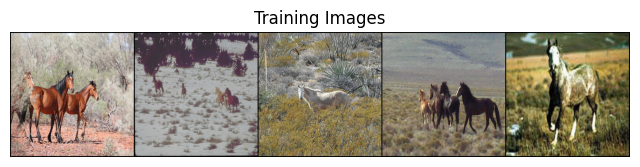

In [10]:
bs = 5
workers = 2
image_size = (256, 256)
dataroot = 'horses_train/'
dataset_horses_train = datasets.ImageFolder(
    dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_train_horses = DataLoader(dataset_horses_train, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_train_horses))
print(real_batch[0].shape)
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

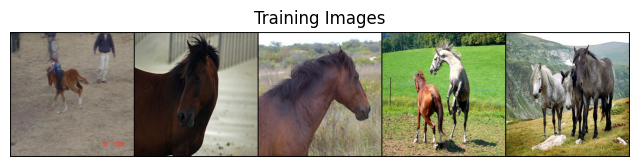

In [11]:
dataroot = 'horses_test/'
dataset_horses_test = datasets.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_test_horses = DataLoader(dataset_horses_test, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_test_horses))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

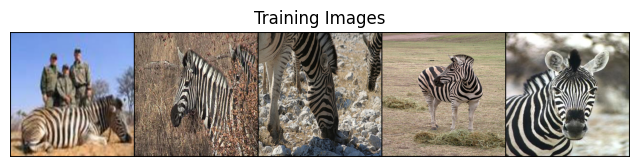

In [12]:
dataroot = 'zebra_train'
dataset_zebra_train = datasets.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_zebra_train = DataLoader(dataset_zebra_train, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_zebra_train))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

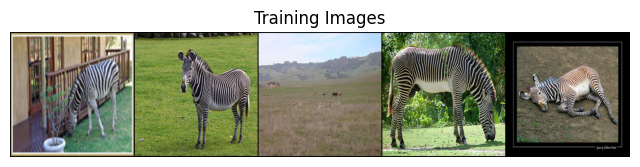

In [13]:
dataroot = 'zebra_test'
dataset_zebra_test = datasets.ImageFolder(
    root=dataroot,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0, 0, 0), (1, 1, 1)),
        ]
    ),
)
dataloader_zebra_test = DataLoader(dataset_zebra_test, batch_size=bs, shuffle=True, num_workers=workers)
real_batch = next(iter(dataloader_zebra_test))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(make_grid(real_batch[0].to(device)[:10], padding=2, normalize=True).cpu(), (1, 2, 0)))

## 定義繪製4個影像的函數：真實的馬、生成的斑馬、真實的斑馬、生成的馬

In [14]:
def plot_images_test(dataloader_test_horses: DataLoader, dataloader_zebra_test: DataLoader) -> None:
    batch_a_test: torch.Tensor = next(iter(dataloader_test_horses))[0].to(device)
    real_a_test = batch_a_test.cpu().detach()
    # 將馬變成斑馬
    fake_b_test: torch.Tensor = G_A2B(batch_a_test).cpu().detach()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((real_a_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Real horses")
    plt.show()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((fake_b_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Fake zebras")
    plt.show()

    batch_b_test: torch.Tensor = next(iter(dataloader_zebra_test))[0].to(device)
    real_b_test = batch_b_test.cpu().detach()
    # 將斑馬變成馬
    fake_a_test: torch.Tensor = G_B2A(batch_b_test).cpu().detach()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((real_b_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Real zebras")
    plt.show()

    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(make_grid((fake_a_test[:4] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0)))
    plt.axis("off")
    plt.title("Fake horses")
    plt.show()

## 定義繪製8個影像的函數

In [15]:
def plot_all_images(image_number: int, dataloader_test_horses: DataLoader, dataloader_zebra_test: DataLoader) -> None:
    # generate fake zebras
    batch_a_test = next(iter(dataloader_test_horses))[0].to(device)
    real_a_test = batch_a_test.cpu().detach()
    fake_b_test = G_A2B(batch_a_test).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((real_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Real horses")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((fake_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Fake zebras")
    plt.show()
    # generate fake horses
    batch_b_test = next(iter(dataloader_zebra_test))[0].to(device)
    real_b_test = batch_b_test.cpu().detach()
    fake_a_test = G_B2A(batch_b_test).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((real_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Real zebras")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((fake_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Fake horses")
    plt.show()
    # identity
    identity_a_test = G_B2A(batch_a_test.cuda()).cpu().detach()
    identity_b_test = G_A2B(batch_b_test.cuda()).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((identity_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Identity horses")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((identity_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Identity zebras")
    plt.show()
    # recovered image
    recover_a_test = G_B2A(fake_b_test.cuda()).cpu().detach()
    recover_b_test = G_A2B(fake_a_test.cuda()).cpu().detach()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((recover_a_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Recovered horses")
    plt.show()
    plt.figure(figsize=(10, 10))
    plt.imshow(
        np.transpose(make_grid((recover_b_test[:image_number] + 1) / 2, padding=2, normalize=True).cpu(), (1, 2, 0))
    )
    plt.axis("off")
    plt.title("Recovered zebras")
    plt.show()

## 定義模型存檔與載入的函數

In [16]:
def save_models(G_A2B: nn.Module, G_B2A: nn.Module, D_A: nn.Module, D_B: nn.Module, name: str) -> None:
    os.makedirs("model_proj3", exist_ok=True)
    torch.save(G_A2B, "model_proj3/" + name + "_G_A2B.pt")
    torch.save(G_B2A, "model_proj3/" + name + "_G_B2A.pt")
    torch.save(D_A, "model_proj3/" + name + "_D_A.pt")
    torch.save(D_B, "model_proj3/" + name + "_D_B.pt")


def load_models(name: str) -> Tuple[nn.Module, nn.Module, nn.Module, nn.Module]:
    G_A2B = torch.load("model_proj3/" + name + "_G_A2B.pt")
    G_B2A = torch.load("model_proj3/" + name + "_G_B2A.pt")
    D_A = torch.load("model_proj3/" + name + "_D_A.pt")
    D_B = torch.load("model_proj3/" + name + "_D_B.pt")
    return G_A2B, G_B2A, D_A, D_B


# save_models(G_A2B, G_B2A, D_A, D_B, "test")
# G_A2B, G_B2A, D_A, D_B= load_models("test")

## 定義生成網路訓練函數

In [17]:
class ResBlock(nn.Module):
    def __init__(self, f):
        super(ResBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(f, f, 3, 1, 1),
            nn.InstanceNorm2d(f),
            nn.ReLU(),
            nn.Conv2d(f, f, 3, 1, 1),
        )
        self.norm = nn.InstanceNorm2d(f)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.norm(self.conv(x) + x))


class Generator(nn.Module):
    def __init__(self, f=64, blocks=9):
        super(Generator, self).__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, f, 7, 1, 0),
            nn.InstanceNorm2d(f),
            nn.ReLU(True),
            nn.Conv2d(f, 2 * f, 3, 2, 1),
            nn.InstanceNorm2d(2 * f),
            nn.ReLU(True),
            nn.Conv2d(2 * f, 4 * f, 3, 2, 1),
            nn.InstanceNorm2d(4 * f),
            nn.ReLU(True),
        ]
        for i in range(int(blocks)):
            layers.append(ResBlock(4 * f))
        layers.extend(
            [
                nn.ConvTranspose2d(4 * f, 4 * 2 * f, 3, 1, 1),
                nn.PixelShuffle(2),
                nn.InstanceNorm2d(2 * f),
                nn.ReLU(True),
                nn.ConvTranspose2d(2 * f, 4 * f, 3, 1, 1),
                nn.PixelShuffle(2),
                nn.InstanceNorm2d(f),
                nn.ReLU(True),
                nn.ReflectionPad2d(3),
                nn.Conv2d(f, 3, 7, 1, 0),
                nn.Tanh(),
            ]
        )
        self.conv = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)

## 定義判別網路訓練函數

In [18]:
nc = 3
ndf = 64


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 128 x 128
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf) x 64 x 64
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*2) x 32 x 32
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.InstanceNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*4) x 16 x 16
            nn.Conv2d(ndf * 4, ndf * 8, 4, 1, 1),
            nn.InstanceNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. (ndf*8) x 15 x 15
            nn.Conv2d(ndf * 8, 1, 4, 1, 1),
            # state size. 1 x 14 x 14
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        return self.main(input)

## 定義判別網路及生成網路的損失函數

In [19]:
def LSGAN_D(real: torch.Tensor, fake: torch.Tensor) -> torch.Tensor:
    return torch.mean((real - 1) ** 2) + torch.mean(fake**2)


def LSGAN_G(fake: torch.Tensor) -> torch.Tensor:
    return torch.mean((fake - 1) ** 2)

## 建立判別及生成網路

In [20]:
G_A2B = Generator().to(device)
G_B2A = Generator().to(device)
D_A = Discriminator().to(device)
D_B = Discriminator().to(device)

# Initialize Loss function
criterion_Im = nn.L1Loss()

# Learning rate for optimizers
lr = 0.0002

# Optimizers
# optimizer_G = optim.Adam(itertools.chain(G_A2B.parameters(), G_B2A.parameters()),
#                                lr=lr, betas=(0.5, 0.999))
optimizer_G_A2B = optim.Adam(G_A2B.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_G_B2A = optim.Adam(G_B2A.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_A = optim.Adam(D_A.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=lr, betas=(0.5, 0.999))

## 定義訓練模型的函數

In [21]:
def training(
    G_A2B: nn.Module,
    G_B2A: nn.Module,
    D_A: nn.Module,
    D_B: nn.Module,
    num_epochs: int,
    name: str,
    old: bool = True,
) -> Tuple[List, List, List, List, List, List, List, List]:
    # Lists to keep track of progress
    img_list = []
    G_losses = []
    D_A_losses = []
    D_B_losses = []

    iters = 0
    FDL_A2B = []
    FDL_B2A = []
    CL_A = []
    CL_B = []
    ID_B2A = []
    ID_A2B = []
    disc_A = []
    disc_B = []

    FDL_A2B_t = []
    FDL_B2A_t = []
    CL_A_t = []
    CL_B_t = []
    ID_B2A_t = []
    ID_A2B_t = []
    disc_A_t = []
    disc_B_t = []

    print("Starting Training Loop...")
    old_a_fake = torch.empty(0)
    old_b_fake = torch.empty(0)
    epoch = 0
    # For each epoch
    for epoch in range(num_epochs):
        # For each batch in the dataloader
        for i, (data_horse, data_zebra) in enumerate(zip(dataloader_train_horses, dataloader_zebra_train), 0):

            # Set model input
            a_real = data_horse[0].to(device)
            b_real = data_zebra[0].to(device)

            # Genrated images
            b_fake = G_A2B(a_real)
            a_rec = G_B2A(b_fake)
            a_fake = G_B2A(b_real)
            b_rec = G_A2B(a_fake)

            # Discriminator A
            optimizer_D_A.zero_grad()
            if (iters > 0 or epoch > 0) and old and iters % 3 == 0:
                rand_int = random.randint(5, old_a_fake.shape[0] - 1)
                Disc_loss_A = LSGAN_D(D_A(a_real), D_A(old_a_fake[rand_int - 5 : rand_int].detach()))
                D_A_losses.append(Disc_loss_A.item())
            else:
                Disc_loss_A = LSGAN_D(D_A(a_real), D_A(a_fake.detach()))
                D_A_losses.append(Disc_loss_A.item())

            Disc_loss_A.backward()
            optimizer_D_A.step()

            # Discriminator B
            optimizer_D_B.zero_grad()
            if (iters > 0 or epoch > 0) and old and iters % 3 == 0:
                rand_int = random.randint(5, old_b_fake.shape[0] - 1)
                Disc_loss_B = LSGAN_D(D_B(b_real), D_B(old_b_fake[rand_int - 5 : rand_int].detach()))
                D_B_losses.append(Disc_loss_B.item())
            else:
                Disc_loss_B = LSGAN_D(D_B(b_real), D_B(b_fake.detach()))
                D_B_losses.append(Disc_loss_B.item())

            Disc_loss_B.backward()
            optimizer_D_B.step()

            # Generator
            optimizer_G_A2B.zero_grad()
            optimizer_G_B2A.zero_grad()

            # Fool discriminator
            Fool_disc_loss_A2B = LSGAN_G(D_B(b_fake))
            Fool_disc_loss_B2A = LSGAN_G(D_A(a_fake))

            # Cycle Consistency    both use the two generators
            Cycle_loss_A = criterion_Im(a_rec, a_real) * 5
            Cycle_loss_B = criterion_Im(b_rec, b_real) * 5

            # Identity loss
            Id_loss_B2A = criterion_Im(G_B2A(a_real), a_real) * 10
            Id_loss_A2B = criterion_Im(G_A2B(b_real), b_real) * 10

            # generator losses
            Loss_G = Fool_disc_loss_A2B + Fool_disc_loss_B2A + Cycle_loss_A + Cycle_loss_B + Id_loss_B2A + Id_loss_A2B
            G_losses.append(Loss_G)

            # Backward propagation
            Loss_G.backward()

            # Optimisation step
            optimizer_G_A2B.step()
            optimizer_G_B2A.step()

            FDL_A2B.append(Fool_disc_loss_A2B)
            FDL_B2A.append(Fool_disc_loss_B2A)
            CL_A.append(Cycle_loss_A)
            CL_B.append(Cycle_loss_B)
            ID_B2A.append(Id_loss_B2A)
            ID_A2B.append(Id_loss_A2B)
            disc_A.append(Disc_loss_A)
            disc_B.append(Disc_loss_B)

            if iters == 0 and epoch == 0:
                old_b_fake = b_fake.clone()
                old_a_fake = a_fake.clone()
            elif old_b_fake.shape[0] == bs * 5 and b_fake.shape[0] == bs:
                rand_int = random.randint(5, 24)
                old_b_fake[rand_int - 5 : rand_int] = b_fake.clone()
                old_a_fake[rand_int - 5 : rand_int] = a_fake.clone()
            elif old_b_fake.shape[0] < 25:
                old_b_fake = torch.cat((b_fake.clone(), old_b_fake))
                old_a_fake = torch.cat((a_fake.clone(), old_a_fake))

            iters += 1
            del data_zebra, data_horse, a_real, b_real, a_fake, b_fake

            if iters % 50 == 0:
                print(
                    f'[{epoch + 1}/{num_epochs}]\tFDL_A2B: {Fool_disc_loss_A2B:.4f}\tFDL_B2A: {Fool_disc_loss_B2A:.4f}\t'
                    f'CL_A: {Cycle_loss_A:.4f}\tCL_B: {Cycle_loss_B:.4f}\tID_B2A: {Id_loss_B2A:.4f}\tID_A2B: {Id_loss_A2B:.4f}\t'
                    f'Loss_D_A: {Disc_loss_A.item():.4f}\tLoss_D_A: {Disc_loss_B.item():.4f}'
                )

    FDL_A2B_t.append(sum(FDL_A2B) / len(FDL_A2B))
    FDL_B2A_t.append(sum(FDL_B2A) / len(FDL_B2A))
    CL_A_t.append(sum(CL_A) / len(CL_A))
    CL_B_t.append(sum(CL_B) / len(CL_B))
    ID_B2A_t.append(sum(ID_B2A) / len(ID_B2A))
    ID_A2B_t.append(sum(ID_A2B) / len(ID_A2B))
    disc_A_t.append(sum(disc_A) / len(disc_A))
    disc_B_t.append(sum(disc_B) / len(disc_B))

    FDL_A2B = []
    FDL_B2A = []
    CL_A = []
    CL_B = []
    ID_B2A = []
    ID_A2B = []
    disc_B = []
    disc_A = []

    iters = 0
    save_models(G_A2B, G_B2A, D_A, D_B, name)
    if epoch % 5 == 0:
        plot_images_test(dataloader_test_horses, dataloader_zebra_test)
    # plot_all_images(4, dataloader_test_horses, dataloader_zebra_test)
    return (FDL_A2B_t, FDL_B2A_t, CL_A_t, CL_B_t, ID_B2A_t, ID_A2B_t, disc_A_t, disc_B_t)

In [ ]:
name = 'basic_training50'
epochs = 20
losses = training(G_A2B, G_B2A, D_A, D_B, epochs, name)

Starting Training Loop...
[1/20]	FDL_A2B: 0.2406	FDL_B2A: 0.2744	CL_A: 0.8114	CL_B: 1.1477	ID_B2A: 1.5885	ID_A2B: 2.0416	Loss_D_A: 0.5308	Loss_D_A: 0.5781
[1/20]	FDL_A2B: 0.2306	FDL_B2A: 0.3131	CL_A: 0.8262	CL_B: 0.7100	ID_B2A: 1.3839	ID_A2B: 1.1821	Loss_D_A: 0.4668	Loss_D_A: 0.4828
[1/20]	FDL_A2B: 0.3670	FDL_B2A: 0.2857	CL_A: 0.5015	CL_B: 0.6457	ID_B2A: 0.9255	ID_A2B: 1.1687	Loss_D_A: 0.5815	Loss_D_A: 0.4624
[1/20]	FDL_A2B: 0.4427	FDL_B2A: 0.3591	CL_A: 0.7757	CL_B: 0.7755	ID_B2A: 1.1337	ID_A2B: 1.3992	Loss_D_A: 0.4927	Loss_D_A: 0.4707
[2/20]	FDL_A2B: 0.1494	FDL_B2A: 0.3955	CL_A: 0.5692	CL_B: 0.6113	ID_B2A: 1.0083	ID_A2B: 1.1560	Loss_D_A: 0.4268	Loss_D_A: 0.4813
[2/20]	FDL_A2B: 0.3041	FDL_B2A: 0.3407	CL_A: 0.4538	CL_B: 0.5131	ID_B2A: 0.9467	ID_A2B: 0.9102	Loss_D_A: 0.4527	Loss_D_A: 0.4690
[2/20]	FDL_A2B: 0.2684	FDL_B2A: 0.3331	CL_A: 0.5074	CL_B: 0.6011	ID_B2A: 0.7832	ID_A2B: 1.0766	Loss_D_A: 0.4913	Loss_D_A: 0.6816
[2/20]	FDL_A2B: 0.3144	FDL_B2A: 0.2964	CL_A: 0.6677	CL_B: 0.4782	ID_B2A

## 存檔

In [ ]:
if not os.path.exists('CycleGAN'):
    os.makedirs('CycleGAN')
# save last check pointing
torch.save(G_A2B.state_dict(), f"CycleGAN/netG_A2B.pth")
torch.save(G_B2A.state_dict(), f"CycleGAN/netG_B2A.pth")
torch.save(D_A.state_dict(), f"CycleGAN/netD_A.pth")
torch.save(D_B.state_dict(), f"CycleGAN/netD_B.pth")

In [ ]:
# 壓縮相關模型
!zip CycleGAN.zip CycleGAN/*.*

In [ ]:
from google.colab import files

files.download('CycleGAN.zip')